# WLS Regression with Acceleration Prototype
This notebook adds the crucial 'Acceleration' metric (the derivative of the slope) to visualize exactly when a trend is accelerating (Rising) or decelerating (Descending).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, glob
import warnings
warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'
LOOKBACK_SHORT = 13
LOOKBACK_LONG = 54
NORMALIZATION_WINDOW = 200
ACCEL_LOOKBACK = 3 # Measure the delta of the slope over 3 days
PLOT_START = '2023-01-01'
PLOT_END = '2023-03-31'

WARMUP_DAYS = NORMALIZATION_WINDOW + LOOKBACK_LONG

In [2]:
# --- MATH FUNCTIONS ---
def calc_wls_regression(series, window):
    reg_line_values = np.full(len(series), np.nan)
    slopes = np.full(len(series), np.nan)
    std_errors = np.full(len(series), np.nan)
    
    x = np.arange(window)
    w = np.arange(1, window + 1)
    sum_w = np.sum(w)
    
    for i in range(window - 1, len(series)):
        y = series.iloc[i - window + 1 : i + 1].values
        
        w_mean_x = np.sum(w * x) / sum_w
        w_mean_y = np.sum(w * y) / sum_w
        
        cov = np.sum(w * (x - w_mean_x) * (y - w_mean_y))
        var_x = np.sum(w * (x - w_mean_x)**2)
        
        slope = cov / var_x
        intercept = w_mean_y - slope * w_mean_x
        
        predictions = slope * x + intercept
        residuals = y - predictions
        mse = np.sum(w * residuals**2) / sum_w
        se = np.sqrt(mse)
        
        reg_line_values[i] = (slope * (window - 1)) + intercept
        slopes[i] = (slope / w_mean_y) * 252 * 100
        std_errors[i] = (se / w_mean_y) * 100
        
    return pd.Series(reg_line_values, index=series.index), \
           pd.Series(slopes, index=series.index), \
           pd.Series(std_errors, index=series.index)

def rolling_minmax(series, window):
    roll_min = series.rolling(window).min()
    roll_max = series.rolling(window).max()
    return ((series - roll_min) / (roll_max - roll_min)) * 100


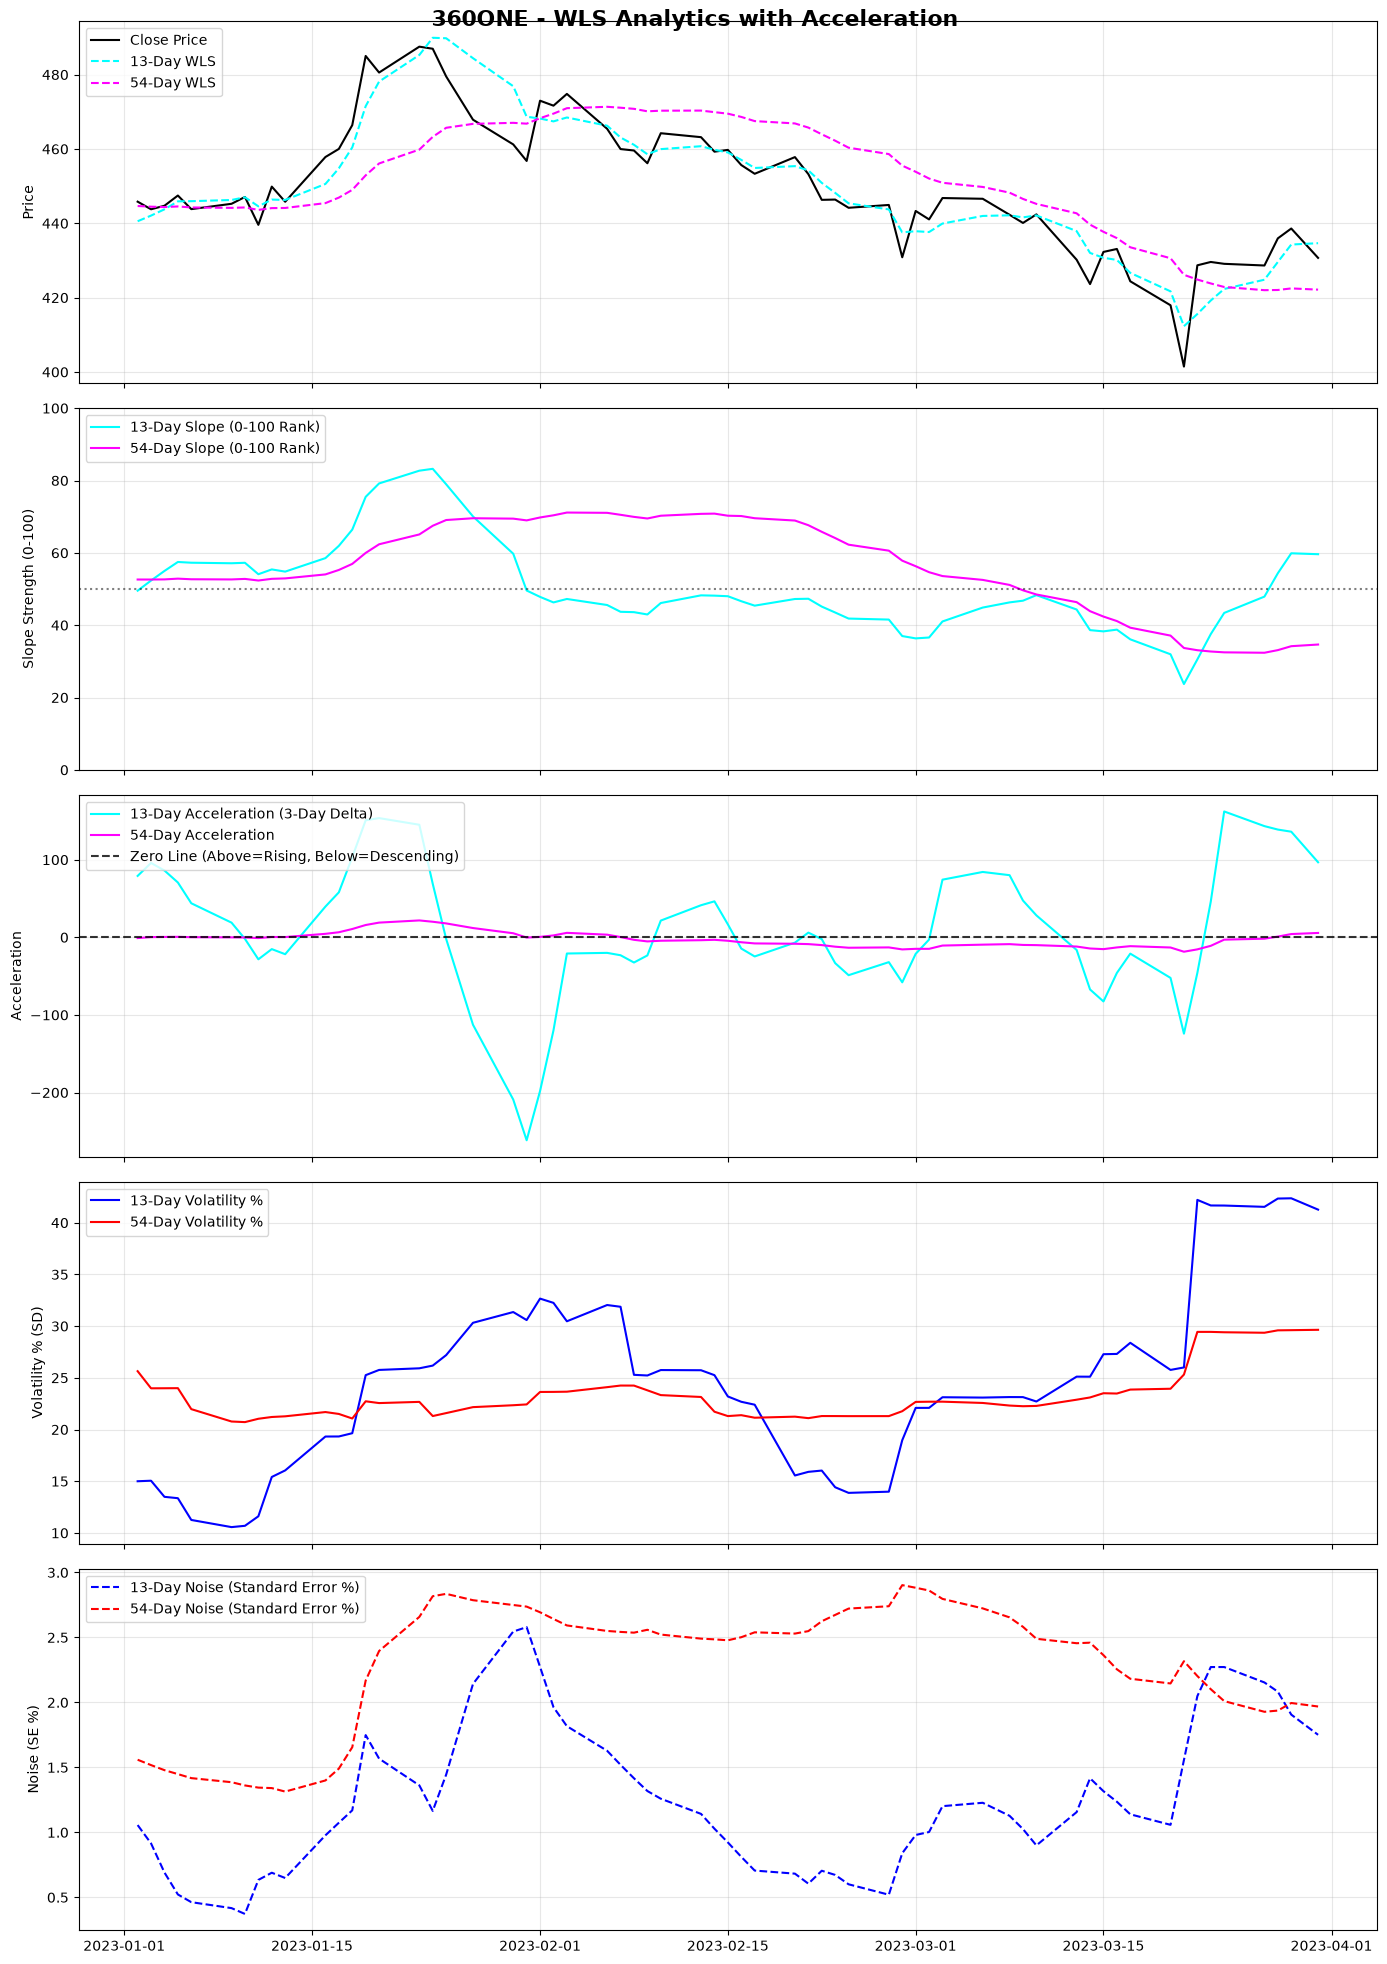

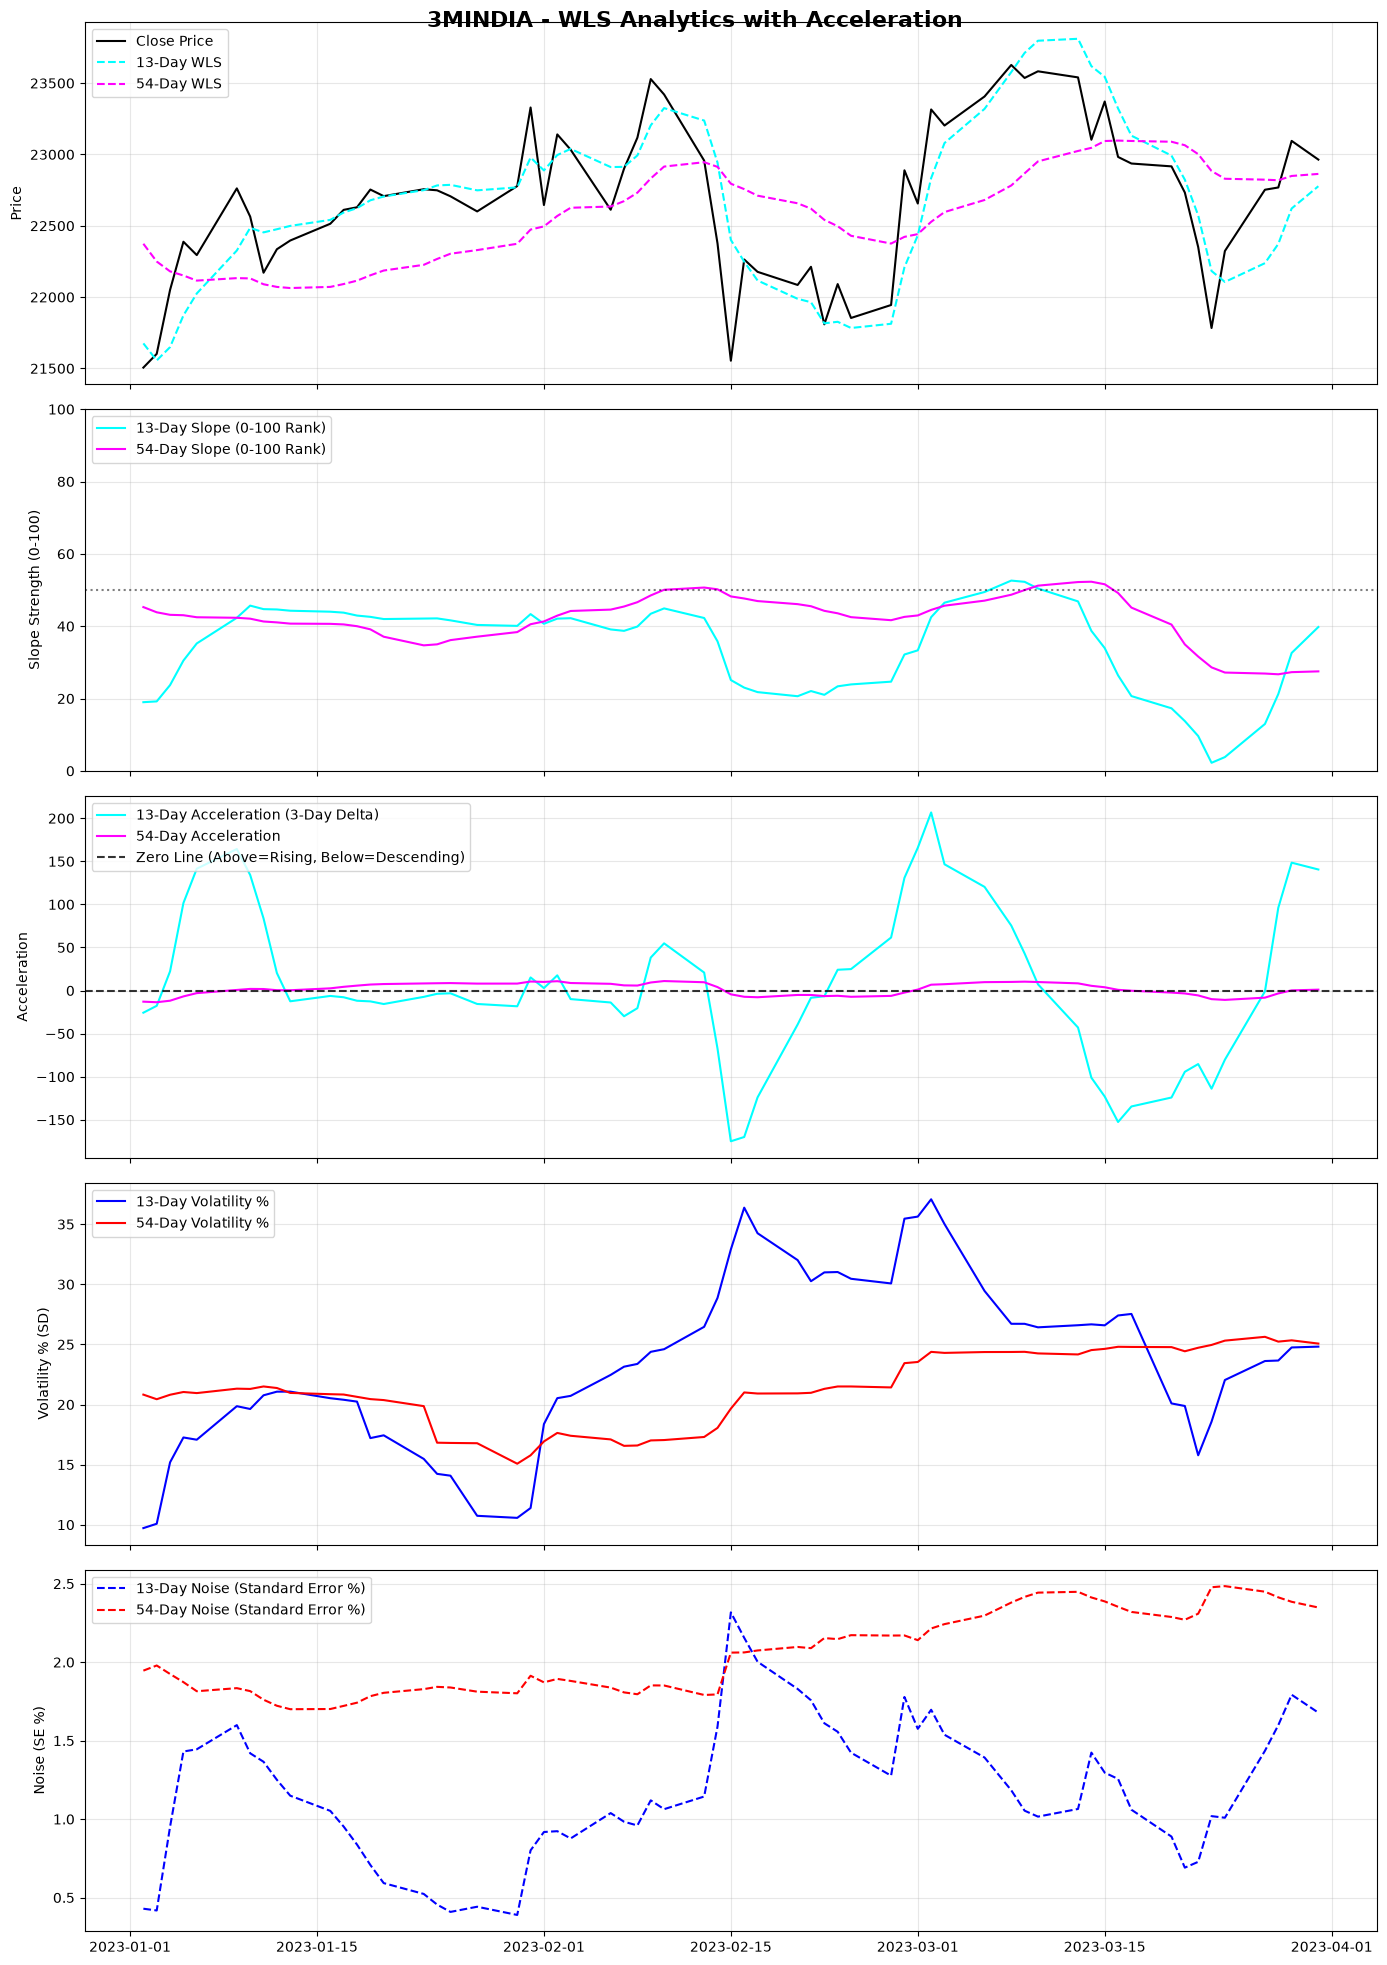

In [3]:
# --- PROCESSING & PLOTTING ---
all_files = glob.glob(os.path.join(DATA_DIR, '*.csv'))[:3]

for file in all_files:
    stock_name = os.path.basename(file).split('.')[0]
    df = pd.read_csv(file)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    
    try:
        start_idx = df[df['Date'] >= PLOT_START].index[0]
        load_start_idx = max(0, start_idx - WARMUP_DAYS)
        end_idx = df[df['Date'] <= PLOT_END].index[-1]
    except IndexError:
        continue 
        
    df = df.iloc[load_start_idx:end_idx+1].copy()
    
    # 1. WLS Regression & Slopes & SE
    df['lr_13'], df['slope_13'], df['se_13'] = calc_wls_regression(df['Close'], LOOKBACK_SHORT)
    df['lr_54'], df['slope_54'], df['se_54'] = calc_wls_regression(df['Close'], LOOKBACK_LONG)
    
    # 2. Acceleration (Delta of the Slope over 3 days)
    df['accel_13'] = df['slope_13'].diff(ACCEL_LOOKBACK)
    df['accel_54'] = df['slope_54'].diff(ACCEL_LOOKBACK)
    
    # 3. Normalize Slopes (Min-Max 0-100 over 200 days)
    df['slope_13_norm'] = rolling_minmax(df['slope_13'], NORMALIZATION_WINDOW)
    df['slope_54_norm'] = rolling_minmax(df['slope_54'], NORMALIZATION_WINDOW)
    
    # 4. Volatility %
    df['vol_13'] = df['Close'].pct_change().rolling(LOOKBACK_SHORT).std() * np.sqrt(252) * 100
    df['vol_54'] = df['Close'].pct_change().rolling(LOOKBACK_LONG).std() * np.sqrt(252) * 100
    
    # Trim Warmup
    plot_df = df[df['Date'] >= PLOT_START].copy()
    
    # --- PLOTTING ---
    fig, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=True)
    fig.suptitle(f"{stock_name} - WLS Analytics with Acceleration", fontsize=16, weight='bold')
    
    # Pane 1: Price and Regressions
    axes[0].plot(plot_df['Date'], plot_df['Close'], color='black', label='Close Price')
    axes[0].plot(plot_df['Date'], plot_df['lr_13'], color='cyan', linestyle='--', label='13-Day WLS')
    axes[0].plot(plot_df['Date'], plot_df['lr_54'], color='magenta', linestyle='--', label='54-Day WLS')
    axes[0].set_ylabel("Price")
    axes[0].legend(loc='upper left')
    axes[0].grid(alpha=0.3)
    
    # Pane 2: Normalized Slopes (0-100 Scale)
    axes[1].plot(plot_df['Date'], plot_df['slope_13_norm'], color='cyan', label='13-Day Slope (0-100 Rank)')
    axes[1].plot(plot_df['Date'], plot_df['slope_54_norm'], color='magenta', label='54-Day Slope (0-100 Rank)')
    axes[1].axhline(50, color='black', linestyle=':', alpha=0.5)
    axes[1].set_ylabel("Slope Strength (0-100)")
    axes[1].set_ylim(0, 100)
    axes[1].legend(loc='upper left')
    axes[1].grid(alpha=0.3)
    
    # Pane 3: Acceleration (Rising/Descending)
    axes[2].plot(plot_df['Date'], plot_df['accel_13'], color='cyan', label='13-Day Acceleration (3-Day Delta)')
    axes[2].plot(plot_df['Date'], plot_df['accel_54'], color='magenta', label='54-Day Acceleration')
    axes[2].axhline(0, color='black', linestyle='--', alpha=0.8, label='Zero Line (Above=Rising, Below=Descending)')
    axes[2].set_ylabel("Acceleration")
    axes[2].legend(loc='upper left')
    axes[2].grid(alpha=0.3)
    
    # Pane 4: Volatility %
    axes[3].plot(plot_df['Date'], plot_df['vol_13'], color='blue', label='13-Day Volatility %')
    axes[3].plot(plot_df['Date'], plot_df['vol_54'], color='red', label='54-Day Volatility %')
    axes[3].set_ylabel("Volatility % (SD)")
    axes[3].legend(loc='upper left')
    axes[3].grid(alpha=0.3)
    
    # Pane 5: Standard Error (Noise %)
    axes[4].plot(plot_df['Date'], plot_df['se_13'], color='blue', linestyle='--', label='13-Day Noise (Standard Error %)')
    axes[4].plot(plot_df['Date'], plot_df['se_54'], color='red', linestyle='--', label='54-Day Noise (Standard Error %)')
    axes[4].set_ylabel("Noise (SE %)")
    axes[4].legend(loc='upper left')
    axes[4].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
